# Big Data Analytics Project - EDA
### Group 55 – NOVA IMS
##### Spring Semester 2024/2025

## 📑 Table of Contents
- 1. Set Up
- 2. EDA
- 3. Feature Engineering, Vectorization, Train-Val-Test Split
- 4. Linear Regression
- 5. Random Forest Regressor
- 6. GBT Regressor
- 7. Update Features
- 8. Results

## Set Up

In [0]:
# Install missing dependencies
%pip install mlflow
%pip install ucimlrepo

Python interpreter will be restarted.
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.1.1
    Not uninstalling typing-extensions at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-269d0cf3-8d75-4cdb-ab74-50aae0a910b4
    Can't uninstall 'typing-extensions'. No files were found to uninstall.
  Attempting uninstall: requests
    Found existing installation: requests 2.27.1
    Not uninstalling requests at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-269d0cf3-8d75-4cdb-ab74-50aae0a910b4
    Can't uninstall 'requests'. No files were found to uninstall.
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 2.0.1
    Not uninstalling markupsafe at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-269d0cf3-8d75-4cdb-ab74-50aae0a910b

In [0]:
# import packages
import os
import pyspark
from pyspark.sql import SparkSession
from functools import reduce
from pyspark.sql import DataFrame
import pyspark.sql.functions as F
from pyspark.sql.functions import col, when, unix_timestamp, dayofweek, dayofmonth, udf, hour, minute, unix_timestamp, concat_ws
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.sql.types import IntegerType, NumericType, StringType, FloatType, DoubleType
import textwrap
from scipy.stats import ks_2samp
from sklearn.feature_selection import mutual_info_regression

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation

import mlflow
import mlflow.pyspark.ml

In [0]:
# Start Spark Session
spark = SparkSession.builder.appName("Predict price") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

In [0]:
# Load the dataset
data = spark.read.parquet('/FileStore/tables/clean/df_projeto_clean.parquet')
data = data.limit(2000000)

In [0]:
# Check the data (number of rows, schema)
print(data.count())
data.printSchema()

2000000
root
 |-- VendorID: string (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: string (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: string (nullable = true)
 |-- DOLocationID: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_holiday: integer (nullable = true)
 |-- pickup_hour_decimal: double (nullable = true)
 |-- trip_duration_minutes: double 

### Select columns that provide value and can be used for the analysis (are accessible at the time of analysis)
Exclude
- VendorID (indicates the TPEP provider that provided record) -> not relevant
- RatecodeID, payment_type, trip_duration_minutes, trip_speed_mph (at the end of the trip) -> not accessible
- fare_amount (at the end of the trip) -> not accessible
- tip_amount (substracted from the total amount since client can decide this)

In [0]:
# drop columns
data_filtered = data.drop("VendorID", "RatecodeID", "fare_amount", 'payment_type', 'trip_duration_minutes', 'trip_speed_mph')

In [0]:
# substract tip_amount
data_filtered = data_filtered.withColumn("total_amount", col("total_amount") - col("tip_amount")).drop("tip_amount")

In [0]:
# features with string datatypes can be turned to integers (except PU_DO_pair) 
[f[0] for f in data_filtered.dtypes if isinstance(data_filtered.schema[f[0]].dataType, (StringType))]

Out[7]: ['passenger_count', 'PULocationID', 'DOLocationID', 'PU_DO_pair']

In [0]:
# Extract day of week and hour features, change datatypes to integer values
df = data_filtered.withColumn("hour", hour("tpep_pickup_datetime")) \
    .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) 

# cast string columns to integer    
for string_col in ['passenger_count', 'PULocationID', 'DOLocationID']:
    df = df.withColumn(string_col, col(string_col).cast("int"))

# check that dtypes ok
[f[0] for f in df.dtypes if isinstance(df.schema[f[0]].dataType, (StringType))]

Out[6]: ['PU_DO_pair']

In [0]:
# we notice that improvement_surcharge, mta_tax, congestion_surcharge are categorical -> we use stringIndexer
print(df.groupBy("improvement_surcharge").count().show())
print(df.groupBy("mta_tax").count().show())
print(df.groupBy("congestion_surcharge").count().show())

+---------------------+-------+
|improvement_surcharge|  count|
+---------------------+-------+
|                  1.0|1999517|
|                  0.3|    483|
+---------------------+-------+

None
+-------+-------+
|mta_tax|  count|
+-------+-------+
|    0.5|1994523|
|    0.0|   5458|
|   0.05|     19|
+-------+-------+

None
+--------------------+-------+
|congestion_surcharge|  count|
+--------------------+-------+
|                 2.5|1871205|
|                 0.0| 128795|
+--------------------+-------+

None


In [0]:
# cast improvement_surcharge, mta_tax, congestion_surcharge values to categorical using stringIndexer
for num_col in ['mta_tax', 'improvement_surcharge', 'congestion_surcharge']:
    df = df.withColumn(num_col, col(num_col).cast("string")) 
    stringIndexer = StringIndexer(inputCol=num_col, outputCol=f'{num_col}_indexed')
    df = stringIndexer.fit(df).transform(df)
    df = df.withColumn(f'{num_col}_indexed', col(f'{num_col}_indexed').cast("int")) 

In [0]:
# # of null values
number_of_nulls = df.filter(
    reduce(lambda x, y: x | y, [col(c).isNull() for c in df.columns])
).count()
print(number_of_nulls)

198


In [0]:
# remove all rows with any null values
df = df.dropna()

## EDA

### Categorical features

In [0]:
# select categorical features
categorical_features = [f[0] for f in df.dtypes if isinstance(df.schema[f[0]].dataType, (StringType, IntegerType))]
categorical_features

Out[13]: ['passenger_count',
 'PULocationID',
 'DOLocationID',
 'mta_tax',
 'improvement_surcharge',
 'congestion_surcharge',
 'Airport_fee',
 'is_weekend',
 'is_holiday',
 'is_shared_ride',
 'has_toll',
 'PU_DO_pair',
 'hour',
 'day_of_week',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

In [0]:
# Remove 'mta_tax', 'improvement_surcharge', 'congestion_surcharge' and use indexed versions; remove PU_DO_pairs as well
categorical_features = ['passenger_count',
 'PULocationID',
 'DOLocationID',
 'Airport_fee',
 'is_weekend',
 'is_holiday',
 'is_shared_ride',
 'has_toll',
 'hour',
 'day_of_week',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

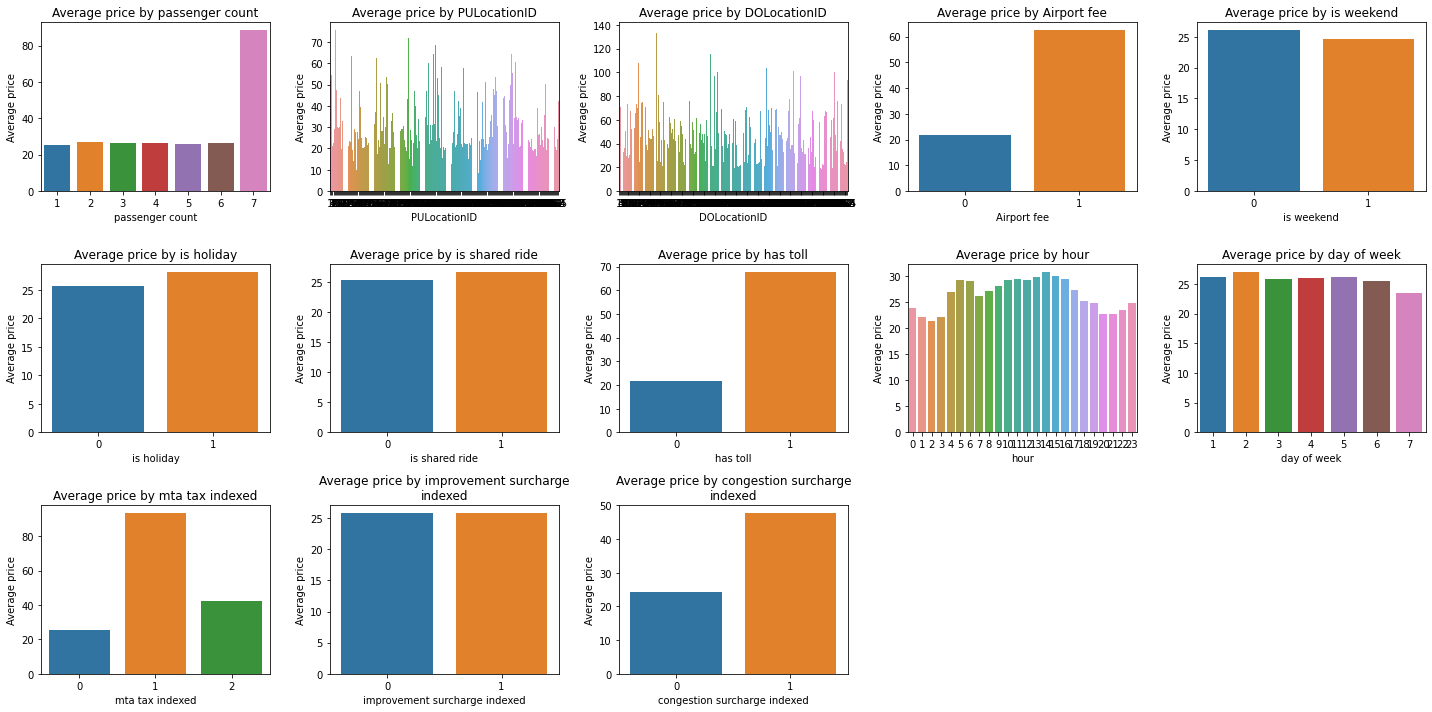

In [0]:
# EDA: categorical features
pd_df = df.toPandas()

# Set up the figure for multiple bar plots
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

# Plot each categorical feature against the mean count
for i, feature in enumerate(categorical_features):
    plot_df = pd_df.groupby(feature)[['total_amount']].mean().reset_index()
    sns.barplot(data=pd_df, x=feature, y="total_amount", ax=axes[i], estimator=np.mean, ci=None)
    axes[i].set_title("\n".join(textwrap.wrap(f'Average price by {feature.replace("_", " ")}', width=40)))
    axes[i].set_xlabel(feature.replace("_", " "))
    axes[i].set_ylabel("Average price")

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])
plt.tight_layout()
plt.show()

In [0]:
# calculate average total_amounts for each group
for feature in categorical_features:
    df.groupBy(feature).avg("total_amount").orderBy("avg(total_amount)").show()

+---------------+------------------+
|passenger_count| avg(total_amount)|
+---------------+------------------+
|              1|25.448955920838717|
|              5|26.129026157652902|
|              3|26.269196932958153|
|              4| 26.42631323340292|
|              6|26.490107977437518|
|              2|26.935610743586864|
|              7|              88.4|
+---------------+------------------+

+------------+------------------+
|PULocationID| avg(total_amount)|
+------------+------------------+
|         175|              8.58|
|         201|               9.1|
|          35|              10.1|
|          98|11.916666666666666|
|          22|             12.15|
|          72|12.514285714285716|
|         147|12.820000000000002|
|          20|              13.9|
|          32|             13.95|
|         178|              14.6|
|          81|             14.95|
|         165|15.099999999999998|
|          94|           15.1375|
|         210|15.299999999999999|
|         139|

#### Mutual information
Calculate the mutual information scores 

In [0]:
mi_features = ['passenger_count',
 #'PULocationID',
 #'DOLocationID',
 'Airport_fee',
 'is_weekend',
 'is_holiday',
 'is_shared_ride',
 'has_toll',
 'hour',
 'day_of_week',
 'mta_tax_indexed',
 'improvement_surcharge_indexed',
 'congestion_surcharge_indexed']

mi_scores = mutual_info_regression(df.select(mi_features).toPandas(), df.select('total_amount').toPandas().squeeze())

mi_df = pd.DataFrame({
    'Feature': mi_features,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

mi_df

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

,Feature,MI Score
6,hour,0.710894
1,Airport_fee,0.267158
5,has_toll,0.248539
10,congestion_surcharge_indexed,0.162275
2,is_weekend,0.082888
7,day_of_week,0.051433
8,mta_tax_indexed,0.014405
3,is_holiday,0.007412
0,passenger_count,0.005119
4,is_shared_ride,0.003785


Exclude: 
- 'day_of_week' (we keep 'is_weekend')
- 'is_holiday' (no big differences on the average total_amount and low MI-score)
- 'PU_DO_pair' (we have PU and DO locations separately) 
- 'has_toll' (we have numeric column 'tolls_amount')
- 'is_shared_ride' (we have 'passenger_count' and for 'is_shared_ride' the average total_amount did not differ significantly and the MI-score is low as well)
- 'improvement_surcharge_indexed' (no big differences on the average total_amount and low MI-score)
 

In [0]:
# final categorical features
categorical_features = ['passenger_count',
 'PULocationID',
 'DOLocationID',
 'Airport_fee',
 'is_weekend',
 'hour',
 'mta_tax_indexed',
 'congestion_surcharge_indexed']

Out[9]: "['passenger_count',\n 'PULocationID',\n 'DOLocationID',\n 'Airport_fee',\n 'hour',\n 'day_of_week',\n 'mta_tax_indexed',\n 'improvement_surcharge_indexed',\n 'congestion_surcharge_indexed']"

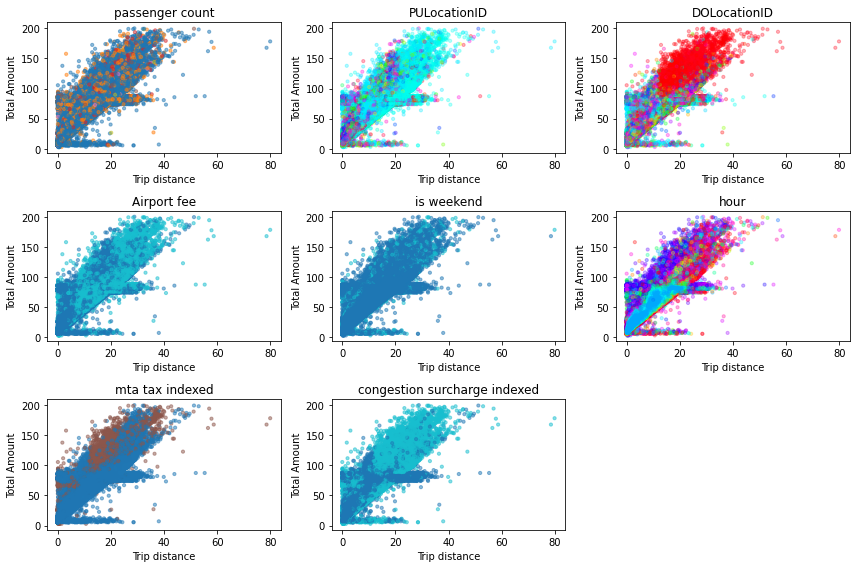

In [0]:
# Plot final features on trip_distance vs. total_amount scatter plot
pandas_df = df.select(["trip_distance", "total_amount"] + categorical_features).toPandas()

# Set up the figure for multiple plots
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot trip_distance vs. total_amount and color points according to the groups in each categorical feature
for i, feature in enumerate(categorical_features):
    if pandas_df[feature].nunique() <= 10:
        axes[i].scatter(
        pandas_df['trip_distance'],
        pandas_df['total_amount'],
        c=pandas_df[feature],
        cmap='tab10',
        alpha=0.5,
        s=10)
    else:
        axes[i].scatter(
            pandas_df['trip_distance'],
            pandas_df['total_amount'],
            c=pandas_df[feature],
            cmap=plt.cm.get_cmap('hsv', pandas_df[feature].nunique()), 
            alpha=0.3,
            s=10)
    axes[i].set_title(f'{feature.replace("_", " ")}')
    axes[i].set_xlabel('Trip distance')
    axes[i].set_ylabel("Total Amount")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### Numerical features

In [0]:
# select numerical features
numerical_features = [f[0] for f in df.dtypes if isinstance(df.schema[f[0]].dataType, DoubleType)]
numerical_features

Out[17]: ['trip_distance',
 'extra',
 'tolls_amount',
 'total_amount',
 'pickup_hour_decimal']

In [0]:
# remove 'total_amount' (target) and 'pickup_hour_decimal' (we have categorical variable hour)
numerical_features = ['trip_distance', 'extra', 'tolls_amount']

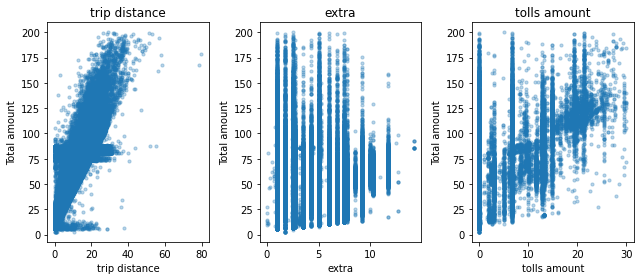

In [0]:
# Plot each numerical feature against total_amount
pandas_df = df.select(numerical_features + ['total_amount']).toPandas() 

# Set up the figure for multiple plots
fig, axes = plt.subplots(1, 3, figsize=(9,4))
axes = axes.flatten()

# Plot each feature against the total_amount
for i, feature in enumerate(numerical_features):
    axes[i].scatter(
            pandas_df[feature],
            pandas_df['total_amount'],
            alpha=0.3,
            s=10)
    axes[i].set_title(f'{feature.replace("_", " ")}')
    axes[i].set_ylabel('Total amount')
    axes[i].set_xlabel(f'{feature.replace("_", " ")}')

plt.tight_layout()
plt.show()

In [0]:
# Create correlation matrix
assembler = VectorAssembler(inputCols=numerical_features + ['total_amount'],
outputCol='features')
df_corr_matrix = assembler.transform(df)
corr_matrix = Correlation.corr(df_corr_matrix, "features", "pearson").head()[0]

In [0]:
# Convert Spark DenseMatrix to NumPy array
corr_array = corr_matrix.toArray()

# Create DataFrame for seaborn
columns = numerical_features + ['total_amount']
corr_df = pd.DataFrame(corr_array, columns=columns, index=columns)

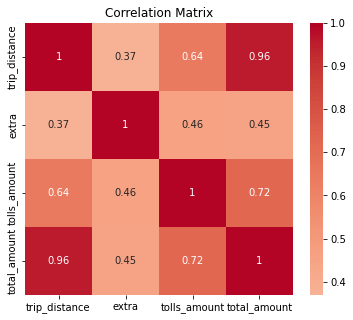

In [0]:
# plot correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [0]:
# final numerical features
numerical_features = ['trip_distance', 'extra', 'tolls_amount']

## Feature Engineering, Vectorization, Train-Test Split

In [0]:
# no need for indexer as all values doubles or integers
df.select(numerical_features+categorical_features).printSchema()

root
 |-- trip_distance: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- Airport_fee: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- mta_tax_indexed: integer (nullable = true)
 |-- congestion_surcharge_indexed: integer (nullable = true)



In [0]:
features = ['trip_distance'] # features for baseline model
features2 = numerical_features # features for LR with all numerical features
features3 = categorical_features + numerical_features # all categorical and numerical features

assembler = VectorAssembler(inputCols=features,
outputCol='features')

assembler2 = VectorAssembler(inputCols=features2, 
outputCol='features2')

assembler3 = VectorAssembler(inputCols=features3, 
outputCol='features3')

df = assembler.transform(df)
df = assembler2.transform(df)
df = assembler3.transform(df)

In [0]:
# Split data
train_data, val_data, test_data = df.select(['features', 'features2', 'features3', 'total_amount']).randomSplit([0.6, 0.2, 0.2], seed=42)

In [0]:
# Evaluators
evaluator_rmse = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="total_amount", predictionCol="prediction", metricName="r2")

## Linear Regression

In [0]:
# Define Linear Regression model and scaler
mlflow.pyspark.ml.autolog(disable=True) 

lr = LinearRegression(featuresCol="features_scaled", labelCol="total_amount")
scaler = StandardScaler(inputCol='features', outputCol="features_scaled", withMean=True, withStd=True)

with mlflow.start_run(run_name="LR_Baseline_Model"):
    # Train the model
    pipeline = Pipeline(stages=[scaler, lr])
    lr_model = pipeline.fit(train_data)

    # Make predictions
    predictions = lr_model.transform(val_data)

    # Evaluate model
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")
    predictions.select("features", "total_amount", "prediction").show(10)

    # Model coefficients and intercept
    print(f"Coefficients: {lr_model.stages[-1].coefficients}")
    print(f"Intercept: {lr_model.stages[-1].intercept}")

Root Mean Squared Error (RMSE): 5.232423886559485
R^2: 0.9182774762994513
MAE: 3.2675491243223176
+--------+------------+-----------------+
|features|total_amount|       prediction|
+--------+------------+-----------------+
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         9.4|10.84760859566825|
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         8.0|10.84760859566825|
|  [0.01]|         5.5|10.84760859566825|
|  [0.01]|         5.5|10.84760859566825|
+--------+------------+-----------------+
only showing top 10 rows

Coefficients: [17.520868225251917]
Intercept: 25.76092171571945


In [0]:
mlflow.pyspark.ml.autolog(disable=True) 

# Define Linear Regression model and scaler
lr = LinearRegression(featuresCol="features2_scaled", labelCol="total_amount")
scaler = StandardScaler(inputCol='features2', outputCol="features2_scaled", withMean=True, withStd=True)

with mlflow.start_run(run_name="LR_Model_Numerical_Features"):
    # Train the model
    pipeline = Pipeline(stages=[scaler, lr])
    lr_model = pipeline.fit(train_data)

    # Make predictions
    predictions = lr_model.transform(val_data)

    # Evaluate model
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")
    predictions.select("features2", "total_amount", "prediction").show(10)

    # Model coefficients and intercept
    print(f"Coefficients: {lr_model.stages[-1].coefficients}")
    print(f"Intercept: {lr_model.stages[-1].intercept}")

Root Mean Squared Error (RMSE): 4.455959003517413
R^2: 0.9407322686546802
MAE: 2.8560961329345043
+--------------+------------+------------------+
|     features2|total_amount|        prediction|
+--------------+------------+------------------+
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         9.4|10.635932727124462|
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         8.0|10.635932727124462|
|[0.01,1.0,0.0]|         5.5|10.635932727124462|
|[0.01,1.0,0.0]|         5.5|10.635932727124462|
+--------------+------------+------------------+
only showing top 10 rows

Coefficients: [15.276243865502382,1.342159587956263,2.7155754598368995]
Intercept: 25.760921715716602


## Random Forest Regressor

In [0]:
# RF model
rf = RandomForestRegressor(featuresCol="features3", labelCol="total_amount")

# Grid search
rf_paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50])
    .addGrid(rf.maxDepth, [3, 5])
    .addGrid(rf.maxBins, [16, 32])
    .build()
)

mlflow.pyspark.ml.autolog(disable=True) 

# rf pipeline and cross validator
rf_pipeline = Pipeline(stages = [rf])
rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3
)

with mlflow.start_run(run_name="RF_Model"):
    rf_cv_model = rf_cv.fit(train_data)
    predictions = rf_cv_model.transform(val_data)

    # Log all tested parameter combinations
    for params, metric in zip(rf_cv_model.getEstimatorParamMaps(), rf_cv_model.avgMetrics):
        param_str = "_".join([f"{param.name}_{val}" for param, val in params.items()])
        mlflow.log_metric(f"cv_rmse_{param_str}", metric)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 5.090972512870454
R^2: 0.9226147480296507
MAE: 3.4736873819312466


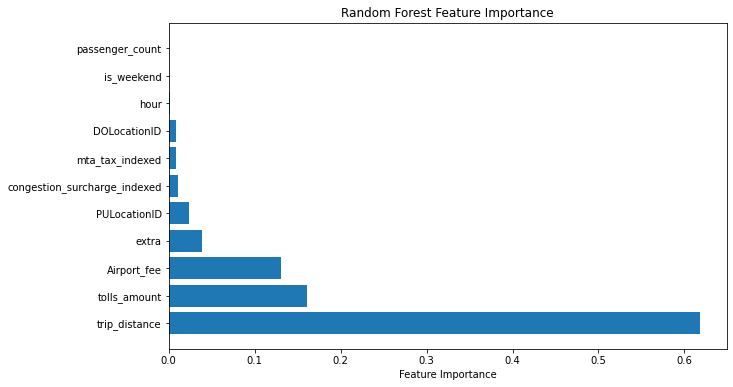

In [0]:
# Look into feature importance in random forest regression
best_rf_model = rf_cv_model.bestModel
rf_model = best_rf_model.stages[-1]

# Get feature importance from the Random Forest model
feature_importances = rf_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features3, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

## GBT Regressor

In [0]:
# GBT model and grid search
gbt = GBTRegressor(featuresCol="features3", labelCol="total_amount")
gbt_paramGrid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxBins, [16, 32])
    .build()
)

# Create a Pipeline (gbt_pipeline)
gbt_pipeline = Pipeline(stages = [gbt])

mlflow.pyspark.ml.autolog(disable=True) 

gbt_cv = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=gbt_paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3
)

with mlflow.start_run(run_name="GBT_Model"):
    gbt_cv_model = gbt_cv.fit(train_data)
    predictions = gbt_cv_model.transform(val_data)

    # Log all tested parameter combinations
    for params, metric in zip(gbt_cv_model.getEstimatorParamMaps(), gbt_cv_model.avgMetrics):
        param_str = "_".join([f"{param.name}_{val}" for param, val in params.items()])
        mlflow.log_metric(f"cv_rmse_{param_str}", metric)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 3.8002418857394833
R^2: 0.9568799577842655
MAE: 2.311597068520879


2025/05/27 14:30:45 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2025/05/27 14:31:19 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/587658695314602/d823491e72434459afd9e665160b9579/artifacts/gbt-best-model/sparkml, flavor: spark). Fall back to return ['pyspark==3.3.2', 'pandas<2']. Set logging level to DEBUG to see the full traceback. 


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

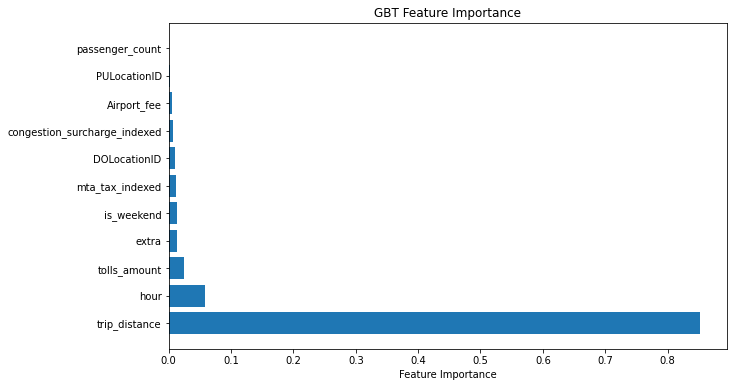

In [0]:
# Look into feature importance in GBT regression
best_gbt_model = gbt_cv_model.bestModel.stages[-1]

# Get feature importances from the GBT model
feature_importances = best_gbt_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features3, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("GBT Feature Importance")
plt.show()

## Update features
Update features based on feature importances to see if we can improve our model

In [0]:
features4 = [#'passenger_count',
 'PULocationID',
 'DOLocationID',
 'Airport_fee',
 'is_weekend',
 'hour',
 'mta_tax_indexed',
 'congestion_surcharge_indexed',
 'trip_distance',
 'extra',
 'tolls_amount']

assembler4 = VectorAssembler(inputCols=features4, 
outputCol='features4')
df = assembler4.transform(df)

In [0]:
# Split data again
train_data, val_data, test_data = df.select(['features', 'features2', 'features3', 'features4', 'total_amount']).randomSplit([0.6, 0.2, 0.2], seed=42)

In [0]:
# RF model
rf = RandomForestRegressor(featuresCol="features4", labelCol="total_amount", numTrees=20, maxDepth=5, maxBins=32)

mlflow.pyspark.ml.autolog(disable=True) 

with mlflow.start_run(run_name="RF_Model_features4"):
    rf_model = rf.fit(train_data)
    predictions = rf_model.transform(val_data)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 4.963550096696543
R^2: 0.9264400347036585
MAE: 3.3746623144836168


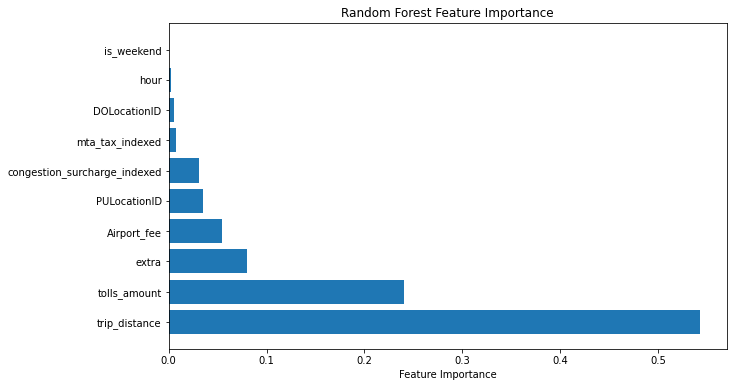

In [0]:
# Get feature importance from the Random Forest model
feature_importances = rf_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features4, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [0]:
# GBT model
gbt = GBTRegressor(featuresCol="features4", labelCol="total_amount", maxDepth=5, maxBins=32)

mlflow.pyspark.ml.autolog(disable=True) 

with mlflow.start_run(run_name="GBT_Model_features4"):
    gbt_model = gbt.fit(train_data)
    predictions = gbt_model.transform(val_data)

    # Evaluate 
    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    mlflow.log_metrics({
        "rmse_val_data": rmse,
        "r2_val_data": r2,
        "mae_val_data": mae
    })

    # Show results
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")
    print(f"MAE: {mae}")

RMSE: 3.8004169675823114
R^2: 0.9568759845054116
MAE: 2.3093504572447836


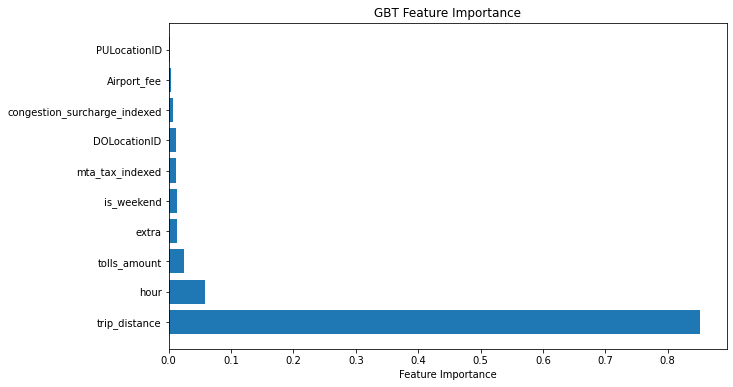

In [0]:
# Get feature importances from the GBT model
feature_importances = gbt_model.featureImportances

# Sort features by importance
sorted_features = sorted(zip(features4, feature_importances), key=lambda x: x[1], reverse=True)
features, importances = zip(*sorted_features)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("GBT Feature Importance")
plt.show()

## Results 
Calculate test error and visualize predictions for the final model

In [0]:
# Get predictions
predictions = best_gbt_model.transform(test_data)

# Select actual and predicted values
results = predictions.select("total_amount", "prediction").toPandas()

In [0]:
rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

# Show results
print(f"RMSE: {rmse}")
print(f"R^2: {r2}")
print(f"MAE: {mae}")

RMSE: 3.8380614890504896
R^2: 0.9558855014609824
MAE: 2.307898696332648


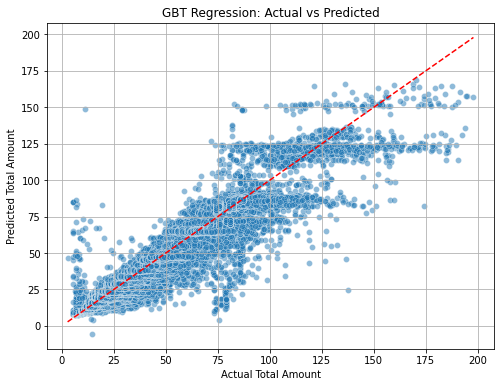

In [0]:
# Predicted vs Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(data=results, x="total_amount", y="prediction", alpha=0.5)
plt.plot([results.total_amount.min(), results.total_amount.max()],
         [results.total_amount.min(), results.total_amount.max()],
         color='red', linestyle='--')
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("GBT Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

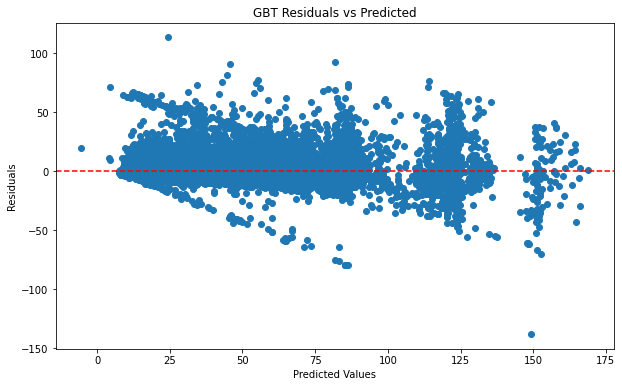

In [0]:
results["residuals"] = results["total_amount"] - results["prediction"]

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(results["prediction"], results["residuals"])
plt.axhline(0, color='red', linestyle="--")  # horizontal line at zero for reference
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("GBT Residuals vs Predicted")
plt.show()